In [6]:
pip install scikit-image

Note: you may need to restart the kernel to use updated packages.Collecting scikit-image
   ---------------------------------------- 0.0/12.9 MB ? eta -:--:--
    --------------------------------------- 0.3/12.9 MB 9.9 MB/s eta 0:00:02
   -- ------------------------------------- 0.9/12.9 MB 11.9 MB/s eta 0:00:02
   ---- ----------------------------------- 1.6/12.9 MB 12.7 MB/s eta 0:00:01
   ------- -------------------------------- 2.5/12.9 MB 14.5 MB/s eta 0:00:01
   ---------- ----------------------------- 3.4/12.9 MB 15.3 MB/s eta 0:00:01
   -------------- ------------------------- 4.5/12.9 MB 17.0 MB/s eta 0:00:01
   ----------------- ---------------------- 5.6/12.9 MB 17.7 MB/s eta 0:00:01
   --------------------- ------------------ 6.9/12.9 MB 19.2 MB/s eta 0:00:01
   -------------------------- ------------- 8.7/12.9 MB 21.3 MB/s eta 0:00:01
   -------------------------------- ------- 10.4/12.9 MB 23.4 MB/s eta 0:00:01
   -------------------------------------- - 12.3/12.9 MB 29.7


[notice] A new release of pip is available: 24.0 -> 24.3.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Question 3 - Subquestion 1, 2 

In [7]:
from skimage import io

In [8]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans

In [9]:
# Load the color image
image_path = r"C:\Users\Jahanvi B Dinesh\OneDrive\Study Period 6\Advanced Probabilistic Machine Learning\homeworks\HW6\Macaw.webp"  # Update this to the correct path if needed
image = io.imread(image_path)

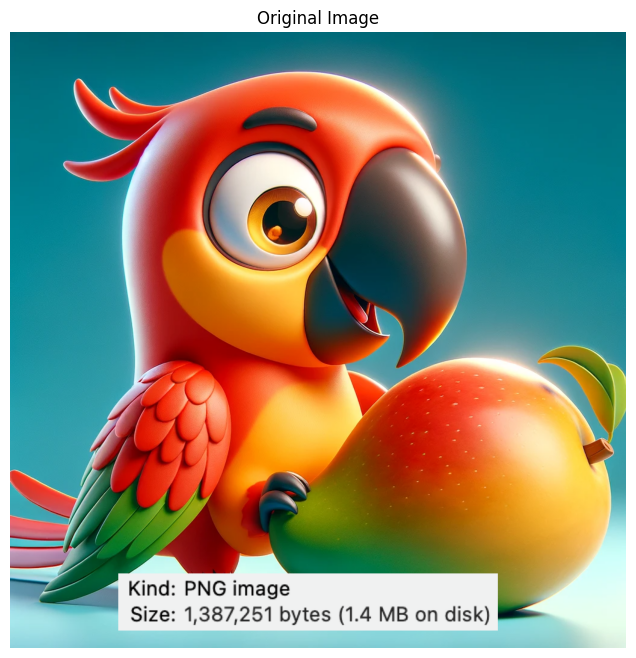

In [10]:
# Display the original image
plt.figure(figsize=(8, 8))
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")
plt.show()

In [11]:
# Flatten the image: (height, width, channels) -> (num_pixels, channels)
image_flat = image.reshape((-1, 3))  # 3 for RGB channels

In [12]:
# Function to apply k-means clustering and display segmented image
def segment_image(image_flat, original_shape, k):
    # Apply KMeans
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(image_flat)
    
    # Replace each pixel with its cluster centroid
    segmented_flat = kmeans.cluster_centers_[kmeans.labels_]
    segmented_image = segmented_flat.reshape(original_shape)
    
    return segmented_image

In [13]:
# Perform k-means clustering for k=2, 4, 8
ks = [2, 4, 8]
segmented_images = []

for k in ks:
    segmented_img = segment_image(image_flat, image.shape, k)
    segmented_images.append((k, segmented_img))

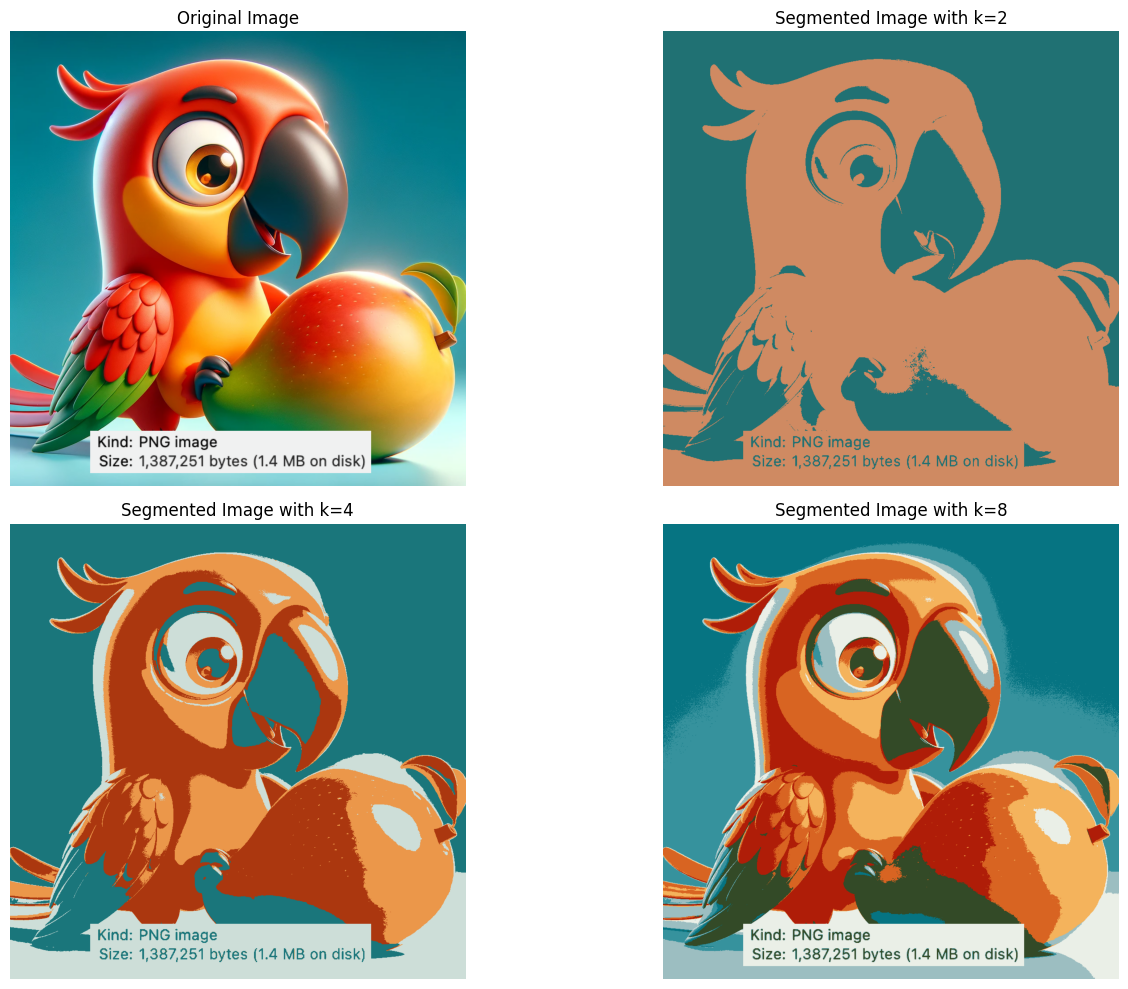

In [14]:
# Display the original and segmented images
plt.figure(figsize=(15, 10))

# Original Image
plt.subplot(2, 2, 1)
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")

# Segmented Images
for i, (k, segmented_img) in enumerate(segmented_images):
    plt.subplot(2, 2, i + 2)
    plt.imshow(segmented_img.astype(np.uint8))  # Convert to integer type
    plt.title(f"Segmented Image with k={k}")
    plt.axis("off")

plt.tight_layout()
plt.show()

Question 3 - Subquestion 3 

1. As K increases - the image has more details and slowly starts looking like the original image. We can also see more colours. 
2. If a small K is used - The image looks very simple with not many colours and details. 
If a large K is used - the image is more detailed and we can see many colours. However this also means that it will take longer to compute and more storage space might be needed to save it. 